# BITS Pilani — Deep Reinforcement Learning — Lab Assignment 1
## Part #1: Adaptive Treatment Recommendation using Multi-Armed Bandits
**Group Number:** 151  
**Submission Deadline:** 8th June, 2026

In [1]:
# ── Cell 1: Imports, Constants, and Random Seed ──────────────────────────────
# We define the group number as a single constant. Every derived parameter
# (number of medicines, success probabilities, dataset seed) flows from G.

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─── Group constant (change only this to adapt for a different group) ───
G = 151

# ─── Set seeds for reproducibility ───
# Using the group number as seed ensures that every run produces identical
# results, which is required for evaluation and grading.
random.seed(G)
np.random.seed(G)

print(f"Group Number (G): {G}")
print(f"Random seeds set to {G} for both random and numpy.")

Group Number (G): 151
Random seeds set to 151 for both random and numpy.


In [2]:
# ── Cell 2: Compute Number of Medicines (K) and Hidden Probabilities ─────────
# K depends on the group number. Each medicine i has a hidden probability P_i
# that determines how likely a patient is to recover when given that medicine.

# Number of medicines available for this group
K = (G % 3) + 5

# Hidden success probability for each medicine i (0 to K-1)
# Formula: P_i = 0.4 + ((G + i) mod 6) * 0.07
success_probabilities = []
for i in range(K):
    p_i = 0.4 + ((G + i) % 6) * 0.07
    success_probabilities.append(round(p_i, 4))

# Display the computed parameters
print(f"{'='*60}")
print(f"  TASK 1: Dataset Design — Group {G}")
print(f"{'='*60}")
print(f"  Total Medicines (K): {K}")
print(f"\n  Hidden Success Probabilities:")
print(f"  {'Medicine':<12} {'Probability':<12}")
print(f"  {'-'*24}")
for i, p in enumerate(success_probabilities):
    marker = " <-- BEST" if p == max(success_probabilities) else ""
    print(f"  Medicine {i:<3} {p:<12}{marker}")

best_medicine = np.argmax(success_probabilities)
print(f"\n  Best medicine: Medicine {best_medicine} (P = {max(success_probabilities)})")

  TASK 1: Dataset Design — Group 151
  Total Medicines (K): 6

  Hidden Success Probabilities:
  Medicine     Probability 
  ------------------------
  Medicine 0   0.47        
  Medicine 1   0.54        
  Medicine 2   0.61        
  Medicine 3   0.68        
  Medicine 4   0.75         <-- BEST
  Medicine 5   0.4         

  Best medicine: Medicine 4 (P = 0.75)


In [3]:
# ── Cell 3: Generate Base Patient DataFrame ──────────────────────────────────
# We create a template dataframe with 1000 patients. Each patient has a fixed
# severity score based on their ID. The treatment-related columns (medicine,
# outcome, utility) are left empty — each strategy will fill its own copy.

NUM_PATIENTS = 1000

# Build the base dataframe
base_df = pd.DataFrame({
    "patient_id": range(NUM_PATIENTS),
    "severity_score": [(pid % 5) + 1 for pid in range(NUM_PATIENTS)]
})

# Add empty columns that each strategy will populate on its own copy
base_df["assigned_medicine"] = np.nan
base_df["clinical_outcome"] = np.nan
base_df["utility_score"] = np.nan

print(f"Base dataset created: {len(base_df)} patients")
print(f"Severity distribution: {base_df['severity_score'].value_counts().sort_index().to_dict()}")
print(f"\nFirst 10 rows of the base dataset:")
base_df.head(10)

Base dataset created: 1000 patients
Severity distribution: {1: 200, 2: 200, 3: 200, 4: 200, 5: 200}

First 10 rows of the base dataset:


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,NaN,NaN,NaN
1,1,2,NaN,NaN,NaN
2,2,3,NaN,NaN,NaN
3,3,4,NaN,NaN,NaN
4,4,5,NaN,NaN,NaN
5,5,1,NaN,NaN,NaN
6,6,2,NaN,NaN,NaN
7,7,3,NaN,NaN,NaN
8,8,4,NaN,NaN,NaN
9,9,5,NaN,NaN,NaN


In [4]:
# ── Cell 4: Simulate Outcome Helper Function ─────────────────────────────────
# This function simulates what happens when a specific medicine is given to a
# patient. It uses the medicine's hidden success probability to draw a binary
# clinical outcome (1=recovered, 0=not recovered), then computes the utility
# score which accounts for patient severity.
#
# KEY DESIGN DECISIONS:
# - clinical_outcome is used to UPDATE bandit statistics (arm selection logic)
# - utility_score is used to COMPUTE cumulative reward (performance metric)
# - Utility formula uses (1 - severity/10) so milder patients (severity=1)
#   benefit more (reward=0.9) than critical patients (severity=5, reward=0.5)

def simulate_outcome(medicine_index, severity):
    """
    Simulate a treatment outcome for a single patient.

    Parameters:
        medicine_index (int): Index of the medicine (0 to K-1)
        severity (int): Patient's disease severity score (1 to 5)

    Returns:
        clinical_outcome (int): 1 if recovered, 0 if not recovered
        utility_score (float): Reward value factoring in severity
            - Recovered + severity 1 -> 0.9 (mild case, high benefit)
            - Recovered + severity 5 -> 0.5 (critical case, lower benefit)
            - Not recovered -> 0.0 (no benefit regardless of severity)
    """
    # Draw recovery outcome using the medicine's hidden probability
    p_success = success_probabilities[medicine_index]
    clinical_outcome = np.random.binomial(1, p_success)

    # Compute utility: higher reward for milder cases when treatment succeeds
    utility_score = clinical_outcome * (1 - severity / 10)

    return clinical_outcome, utility_score


# ─── Quick verification of the helper function ───
print("Simulate Outcome — Verification:")
print(f"  {'Medicine':<10} {'Severity':<10} {'Outcome':<10} {'Utility':<10}")
print(f"  {'-'*40}")
for med, sev in [(0, 1), (0, 5), (4, 1), (4, 3), (4, 5)]:
    outcome, utility = simulate_outcome(med, sev)
    print(f"  Med {med:<6} Sev {sev:<6} {outcome:<10} {utility:<10.2f}")

print(f"\nUtility formula: outcome * (1 - severity/10)")
print(f"If outcome=1: sev=1 -> 0.9 | sev=5 -> 0.5 | outcome=0 -> 0.0")

Simulate Outcome — Verification:
  Medicine   Severity   Outcome    Utility   
  ----------------------------------------
  Med 0      Sev 1      1          0.90      
  Med 0      Sev 5      0          0.00      
  Med 4      Sev 1      1          0.90      
  Med 4      Sev 3      0          0.00      
  Med 4      Sev 5      1          0.50      

Utility formula: outcome * (1 - severity/10)
If outcome=1: sev=1 -> 0.9 | sev=5 -> 0.5 | outcome=0 -> 0.0


## Task 2: Immediate Exploitation Strategy (Greedy) — 1 Mark
> *"Once a treatment appears best, continue prescribing only that treatment for all future patients."*

**Approach:**  
1. **Exploration phase:** Test each of the K medicines exactly 10 times (first 60 patients)  
2. **Exploitation phase:** Pick the medicine with the highest average clinical_outcome, use it for all remaining 940 patients  
3. Track cumulative reward (sum of utility_score) at each step

In [5]:
# ── Cell 5: Greedy Strategy — Function Definition ────────────────────────────
# The greedy (exploit-only) strategy has two phases:
# Phase 1 (Exploration): Each medicine is tested exactly 10 times. We use
#   clinical_outcome (not utility) to estimate which arm is best.
# Phase 2 (Exploitation): The medicine with the highest observed success rate
#   is locked in for all remaining patients.

def run_greedy_strategy(base_df, K, num_explore_per_arm=10):
    """
    Run the immediate exploitation (greedy) strategy.

    Parameters:
        base_df (DataFrame): Template dataframe with patient_id and severity_score
        K (int): Number of available medicines
        num_explore_per_arm (int): How many times to test each medicine initially

    Returns:
        df (DataFrame): Completed dataframe with all columns filled
        cumulative_rewards (list): Running total of utility_score at each patient
        arm_counts (list): How many times each medicine was selected
    """
    df = base_df.copy()
    
    # Tracking variables for each arm
    arm_success_count = [0] * K    # total recoveries per arm (for selection)
    arm_trial_count = [0] * K      # total trials per arm
    cumulative_rewards = []         # running sum of utility_score
    running_total = 0.0

    total_explore = K * num_explore_per_arm  # 6 * 10 = 60 patients for exploration

    for idx in range(len(df)):
        severity = df.at[idx, "severity_score"]

        # ── Phase 1: Exploration (round-robin, 10 per arm) ──
        if idx < total_explore:
            medicine = idx % K  # cycle through 0,1,2,3,4,5,0,1,2,...
        # ── Phase 2: Exploitation (lock onto best arm) ──
        else:
            # Pick the arm with the highest average clinical_outcome
            avg_success = [
                arm_success_count[m] / arm_trial_count[m] 
                if arm_trial_count[m] > 0 else 0
                for m in range(K)
            ]
            medicine = int(np.argmax(avg_success))

        # Simulate the treatment outcome
        outcome, utility = simulate_outcome(medicine, severity)

        # Record in dataframe
        df.at[idx, "assigned_medicine"] = medicine
        df.at[idx, "clinical_outcome"] = outcome
        df.at[idx, "utility_score"] = utility

        # Update bandit statistics using clinical_outcome (not utility)
        arm_success_count[medicine] += outcome
        arm_trial_count[medicine] += 1

        # Track cumulative reward using utility_score
        running_total += utility
        cumulative_rewards.append(running_total)

    return df, cumulative_rewards, arm_trial_count


print("Greedy strategy function defined successfully.")
print(f"Exploration budget: {K} medicines x 10 trials = {K * 10} patients")
print(f"Exploitation phase: remaining {NUM_PATIENTS - K * 10} patients")

Greedy strategy function defined successfully.
Exploration budget: 6 medicines x 10 trials = 60 patients
Exploitation phase: remaining 940 patients


In [6]:
# ── Cell 6: Run Greedy Strategy and Display Results ──────────────────────────
# Execute the greedy strategy on 1000 patients. We print a summary of which
# arm was selected, how many times, and the final cumulative reward.

greedy_df, greedy_rewards, greedy_arm_counts = run_greedy_strategy(base_df, K)

# ─── Summary statistics ───
print(f"{'='*60}")
print(f"  TASK 2: Greedy Strategy — Results Summary")
print(f"{'='*60}")
print(f"\n  Arm Selection Counts:")
print(f"  {'Medicine':<12} {'Times Used':<12} {'Success Rate':<14}")
print(f"  {'-'*38}")
for m in range(K):
    count = greedy_arm_counts[m]
    if count > 0:
        success_rate = greedy_df[greedy_df["assigned_medicine"] == m]["clinical_outcome"].mean()
        print(f"  Medicine {m:<3} {count:<12} {success_rate:<14.4f}")
    else:
        print(f"  Medicine {m:<3} {count:<12} {'N/A':<14}")

locked_arm = int(greedy_df.iloc[K * 10]["assigned_medicine"])
print(f"\n  Arm locked after exploration: Medicine {locked_arm}")
print(f"  Final Cumulative Reward: {greedy_rewards[-1]:.4f}")

  TASK 2: Greedy Strategy — Results Summary

  Arm Selection Counts:
  Medicine     Times Used   Success Rate  
  --------------------------------------
  Medicine 0   10           0.6000        
  Medicine 1   10           0.2000        
  Medicine 2   10           0.6000        
  Medicine 3   12           0.6667        
  Medicine 4   948          0.7437        
  Medicine 5   10           0.6000        

  Arm locked after exploration: Medicine 4
  Final Cumulative Reward: 509.2000


In [7]:
# ── Cell 7: Greedy Strategy — All 1000 Iteration Details ─────────────────────
# Printing every iteration as required by the assignment. We use a compact
# table format with cumulative reward tracked at each step.

# Add cumulative reward column for display
greedy_display = greedy_df.copy()
greedy_display["cumulative_reward"] = greedy_rewards
greedy_display["assigned_medicine"] = greedy_display["assigned_medicine"].astype(int)
greedy_display["clinical_outcome"] = greedy_display["clinical_outcome"].astype(int)

# Set display options to show all 1000 rows
pd.set_option("display.max_rows", 1010)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("GREEDY STRATEGY — Complete Iteration Log (1000 patients)")
print("="*90)
print(greedy_display.to_string(index=False))

# Reset display options
pd.reset_option("display.max_rows")
pd.reset_option("display.width")
pd.reset_option("display.float_format")

GREEDY STRATEGY — Complete Iteration Log (1000 patients)
 patient_id  severity_score  assigned_medicine  clinical_outcome  utility_score  cumulative_reward
          0               1                  0                 1         0.9000             0.9000
          1               2                  1                 0         0.0000             0.9000
          2               3                  2                 0         0.0000             0.9000
          3               4                  3                 1         0.6000             1.5000
          4               5                  4                 1         0.5000             2.0000
          5               1                  5                 1         0.9000             2.9000
          6               2                  0                 1         0.8000             3.7000
          7               3                  1                 0         0.0000             3.7000
          8               4                  2      

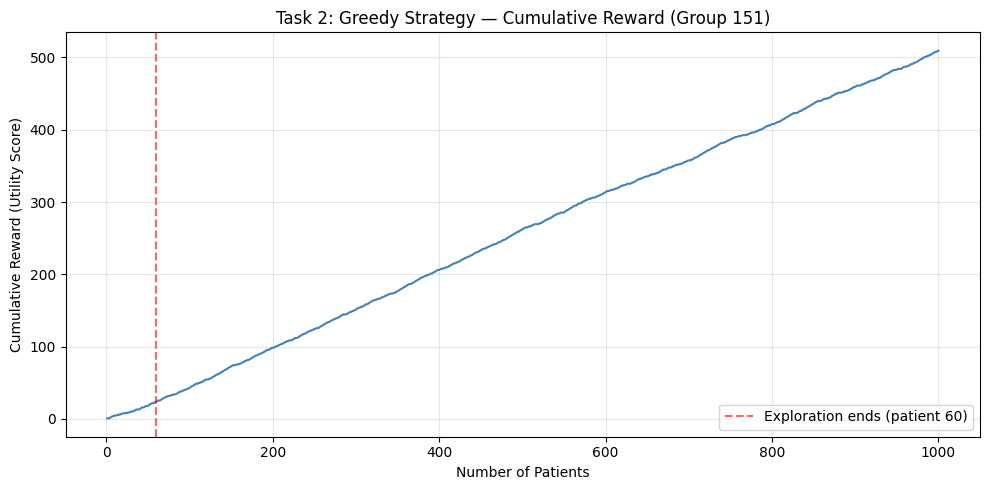


Final cumulative reward after 1000 patients: 509.2000


In [8]:
# ── Cell 8: Greedy Strategy — Cumulative Reward Visualization ────────────────
# A quick standalone plot to verify the greedy strategy's performance before
# we move to the other strategies. The final comparison plot comes in Task 5.

plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_PATIENTS + 1), greedy_rewards, color="steelblue", linewidth=1.5)
plt.axvline(x=K * 10, color="red", linestyle="--", alpha=0.6, label=f"Exploration ends (patient {K*10})")
plt.xlabel("Number of Patients")
plt.ylabel("Cumulative Reward (Utility Score)")
plt.title(f"Task 2: Greedy Strategy — Cumulative Reward (Group {G})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal cumulative reward after 1000 patients: {greedy_rewards[-1]:.4f}")

## Task 3: Controlled Clinical Trial Strategy (Epsilon-Greedy) — 1.5 Marks
> *"Most patients should receive the current best treatment, but occasionally another treatment should be tested to discover hidden opportunities."*

**Approach:**  
1. With probability (1 - ε): exploit the current best arm (highest avg clinical_outcome)  
2. With probability ε: explore a random arm  
3. Run with ε = 0.10 (main), then compare ε = 0.01 and ε = 0.50  
4. Analyze the exploration-exploitation trade-off across all three

In [9]:
# ── Cell 9: Epsilon-Greedy Strategy — Reusable Function ──────────────────────
# This function is parameterized by epsilon so we can reuse it for all three
# variants (0.01, 0.10, 0.50) without code duplication.
#
# At each step:
#   - With probability epsilon: pick a random medicine (exploration)
#   - With probability (1 - epsilon): pick the medicine with the highest
#     observed average clinical_outcome so far (exploitation)
#
# For the very first patient (no data yet), we always explore randomly.

def run_epsilon_greedy(base_df, K, epsilon, seed_value=None):
    """
    Run the epsilon-greedy strategy for the MAB problem.

    Parameters:
        base_df (DataFrame): Template dataframe with patient_id and severity_score
        K (int): Number of available medicines
        epsilon (float): Exploration probability (0 to 1)
        seed_value (int or None): If provided, reset numpy seed for comparability

    Returns:
        df (DataFrame): Completed dataframe with all columns filled
        cumulative_rewards (list): Running total of utility_score at each patient
        arm_counts (list): How many times each medicine was selected
    """
    # Reset seed so each epsilon variant sees the same random stream
    if seed_value is not None:
        np.random.seed(seed_value)

    df = base_df.copy()

    # Tracking variables for each arm
    arm_success_count = [0] * K    # total recoveries per arm
    arm_trial_count = [0] * K      # total trials per arm
    cumulative_rewards = []         # running sum of utility_score
    running_total = 0.0

    for idx in range(len(df)):
        severity = df.at[idx, "severity_score"]

        # Decide: explore or exploit
        if sum(arm_trial_count) == 0 or np.random.random() < epsilon:
            # ── Exploration: pick a random medicine ──
            medicine = np.random.randint(0, K)
        else:
            # ── Exploitation: pick best observed arm ──
            avg_success = [
                arm_success_count[m] / arm_trial_count[m]
                if arm_trial_count[m] > 0 else 0.0
                for m in range(K)
            ]
            medicine = int(np.argmax(avg_success))

        # Simulate the treatment outcome
        outcome, utility = simulate_outcome(medicine, severity)

        # Record in dataframe
        df.at[idx, "assigned_medicine"] = medicine
        df.at[idx, "clinical_outcome"] = outcome
        df.at[idx, "utility_score"] = utility

        # Update bandit statistics using clinical_outcome
        arm_success_count[medicine] += outcome
        arm_trial_count[medicine] += 1

        # Track cumulative reward using utility_score
        running_total += utility
        cumulative_rewards.append(running_total)

    return df, cumulative_rewards, arm_trial_count


print("Epsilon-greedy function defined successfully.")
print(f"Will be tested with epsilon = 0.01, 0.10, 0.50")

Epsilon-greedy function defined successfully.
Will be tested with epsilon = 0.01, 0.10, 0.50


In [10]:
# ── Cell 10: Run Epsilon-Greedy with ε = 0.10 (Main Variant) ─────────────────
# This is the primary variant requested by the assignment. We use a fresh
# seed (G) so results are reproducible and independent of prior cells.

eps_10_df, eps_10_rewards, eps_10_counts = run_epsilon_greedy(
    base_df, K, epsilon=0.10, seed_value=G
)

# ─── Summary ───
print(f"{'='*60}")
print(f"  TASK 3: Epsilon-Greedy (ε = 0.10) — Results Summary")
print(f"{'='*60}")
print(f"\n  Arm Selection Counts:")
print(f"  {'Medicine':<12} {'Times Used':<12} {'Success Rate':<14}")
print(f"  {'-'*38}")
for m in range(K):
    count = eps_10_counts[m]
    if count > 0:
        sr = eps_10_df[eps_10_df["assigned_medicine"] == m]["clinical_outcome"].mean()
        print(f"  Medicine {m:<3} {count:<12} {sr:<14.4f}")

print(f"\n  Final Cumulative Reward (ε=0.10): {eps_10_rewards[-1]:.4f}")

# ─── Full iteration log ───
eps_10_display = eps_10_df.copy()
eps_10_display["cumulative_reward"] = eps_10_rewards
eps_10_display["assigned_medicine"] = eps_10_display["assigned_medicine"].astype(int)
eps_10_display["clinical_outcome"] = eps_10_display["clinical_outcome"].astype(int)

pd.set_option("display.max_rows", 1010)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print(f"\nEPSILON-GREEDY (ε=0.10) — Complete Iteration Log (1000 patients)")
print("="*90)
print(eps_10_display.to_string(index=False))

pd.reset_option("display.max_rows")
pd.reset_option("display.width")
pd.reset_option("display.float_format")

  TASK 3: Epsilon-Greedy (ε = 0.10) — Results Summary

  Arm Selection Counts:
  Medicine     Times Used   Success Rate  
  --------------------------------------
  Medicine 0   21           0.5238        
  Medicine 1   27           0.5926        
  Medicine 2   12           0.5000        
  Medicine 3   22           0.7273        
  Medicine 4   893          0.7469        
  Medicine 5   25           0.3200        

  Final Cumulative Reward (ε=0.10): 503.0000

EPSILON-GREEDY (ε=0.10) — Complete Iteration Log (1000 patients)
 patient_id  severity_score  assigned_medicine  clinical_outcome  utility_score  cumulative_reward
          0               1                  0                 0         0.0000             0.0000
          1               2                  0                 0         0.0000             0.0000
          2               3                  0                 1         0.7000             0.7000
          3               4                  0                 1       

In [11]:
# ── Cell 11: Run Epsilon-Greedy with ε = 0.01 and ε = 0.50 ──────────────────
# These two variants demonstrate the extremes of the exploration-exploitation
# trade-off. Each gets its own seed reset for fair comparison.

# ─── ε = 0.01 (almost pure exploitation) ───
eps_01_df, eps_01_rewards, eps_01_counts = run_epsilon_greedy(
    base_df, K, epsilon=0.01, seed_value=G
)

print(f"{'='*60}")
print(f"  Epsilon-Greedy (ε = 0.01) — Results Summary")
print(f"{'='*60}")
print(f"\n  Arm Selection Counts:")
for m in range(K):
    count = eps_01_counts[m]
    if count > 0:
        sr = eps_01_df[eps_01_df["assigned_medicine"] == m]["clinical_outcome"].mean()
        print(f"  Medicine {m}: {count} trials, success rate = {sr:.4f}")
print(f"  Final Cumulative Reward: {eps_01_rewards[-1]:.4f}")

# Full iteration log for ε = 0.01
eps_01_display = eps_01_df.copy()
eps_01_display["cumulative_reward"] = eps_01_rewards
eps_01_display["assigned_medicine"] = eps_01_display["assigned_medicine"].astype(int)
eps_01_display["clinical_outcome"] = eps_01_display["clinical_outcome"].astype(int)

pd.set_option("display.max_rows", 1010)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print(f"\nEPSILON-GREEDY (ε=0.01) — Complete Iteration Log")
print("="*90)
print(eps_01_display.to_string(index=False))

pd.reset_option("display.max_rows")
pd.reset_option("display.width")
pd.reset_option("display.float_format")

# ─── ε = 0.50 (heavy exploration) ───
eps_50_df, eps_50_rewards, eps_50_counts = run_epsilon_greedy(
    base_df, K, epsilon=0.50, seed_value=G
)

print(f"\n{'='*60}")
print(f"  Epsilon-Greedy (ε = 0.50) — Results Summary")
print(f"{'='*60}")
print(f"\n  Arm Selection Counts:")
for m in range(K):
    count = eps_50_counts[m]
    if count > 0:
        sr = eps_50_df[eps_50_df["assigned_medicine"] == m]["clinical_outcome"].mean()
        print(f"  Medicine {m}: {count} trials, success rate = {sr:.4f}")
print(f"  Final Cumulative Reward: {eps_50_rewards[-1]:.4f}")

# Full iteration log for ε = 0.50
eps_50_display = eps_50_df.copy()
eps_50_display["cumulative_reward"] = eps_50_rewards
eps_50_display["assigned_medicine"] = eps_50_display["assigned_medicine"].astype(int)
eps_50_display["clinical_outcome"] = eps_50_display["clinical_outcome"].astype(int)

pd.set_option("display.max_rows", 1010)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print(f"\nEPSILON-GREEDY (ε=0.50) — Complete Iteration Log")
print("="*90)
print(eps_50_display.to_string(index=False))

pd.reset_option("display.max_rows")
pd.reset_option("display.width")
pd.reset_option("display.float_format")

  Epsilon-Greedy (ε = 0.01) — Results Summary

  Arm Selection Counts:
  Medicine 0: 424 trials, success rate = 0.4976
  Medicine 2: 495 trials, success rate = 0.5737
  Medicine 3: 78 trials, success rate = 0.6667
  Medicine 4: 2 trials, success rate = 0.5000
  Medicine 5: 1 trials, success rate = 0.0000
  Final Cumulative Reward: 386.6000

EPSILON-GREEDY (ε=0.01) — Complete Iteration Log
 patient_id  severity_score  assigned_medicine  clinical_outcome  utility_score  cumulative_reward
          0               1                  0                 0         0.0000             0.0000
          1               2                  0                 0         0.0000             0.0000
          2               3                  0                 1         0.7000             0.7000
          3               4                  0                 1         0.6000             1.3000
          4               5                  0                 0         0.0000             1.3000
          5   

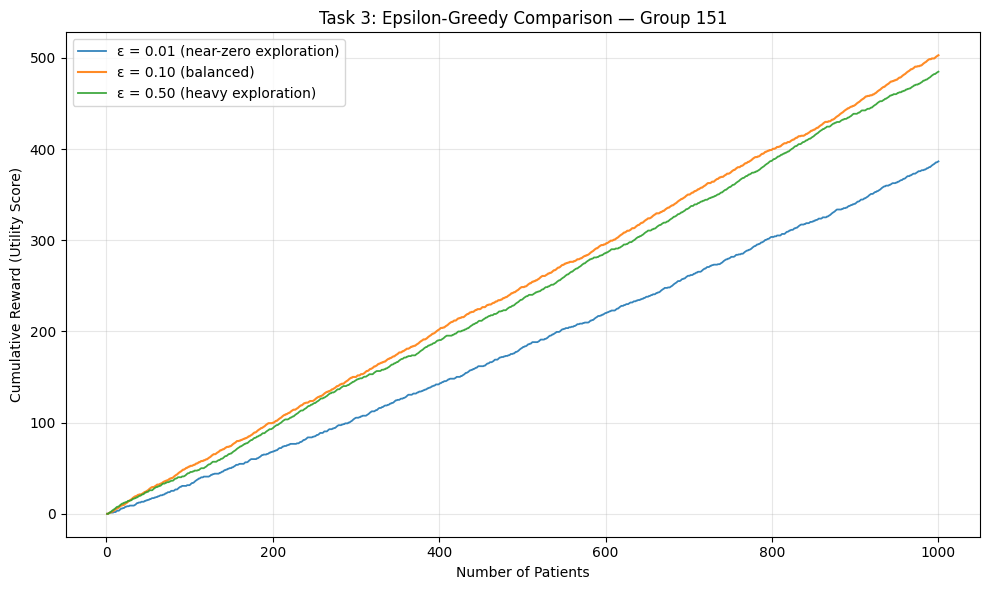


  TASK 3: Exploration-Exploitation Analysis

  ε = 0.01 (Near-zero exploration):
    Cumulative Reward = 386.6000
    With only 1% exploration, this strategy risks locking onto a suboptimal
    arm early if initial samples are unlucky. It barely explores alternatives,
    so it may never discover the true best medicine. However, if it does find
    the best arm early, it wastes very few trials on suboptimal choices.

  ε = 0.10 (Balanced exploration):
    Cumulative Reward = 503.0000
    With 10% exploration, there is a reasonable chance of discovering the best
    arm while still exploiting the current best most of the time. This is the
    recommended default for many practical MAB applications.

  ε = 0.50 (Heavy exploration):
    Cumulative Reward = 485.0000
    With 50% exploration, half the patients receive a random medicine instead
    of the current best. This wastes too many trials on known-inferior arms,
    significantly reducing total reward even though it thoroughly explo

In [12]:
# ── Cell 12: Epsilon-Greedy — Comparison Plot and Analysis ────────────────────
# We overlay the cumulative reward curves for all three epsilon values to
# visually demonstrate the exploration-exploitation trade-off.

plt.figure(figsize=(10, 6))
plt.plot(range(1, NUM_PATIENTS + 1), eps_01_rewards, 
         label="ε = 0.01 (near-zero exploration)", linewidth=1.3, alpha=0.9)
plt.plot(range(1, NUM_PATIENTS + 1), eps_10_rewards, 
         label="ε = 0.10 (balanced)", linewidth=1.5, alpha=0.9)
plt.plot(range(1, NUM_PATIENTS + 1), eps_50_rewards, 
         label="ε = 0.50 (heavy exploration)", linewidth=1.3, alpha=0.9)
plt.xlabel("Number of Patients")
plt.ylabel("Cumulative Reward (Utility Score)")
plt.title(f"Task 3: Epsilon-Greedy Comparison — Group {G}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ─── Written analysis ───
print(f"\n{'='*60}")
print(f"  TASK 3: Exploration-Exploitation Analysis")
print(f"{'='*60}")
print(f"""
  ε = 0.01 (Near-zero exploration):
    Cumulative Reward = {eps_01_rewards[-1]:.4f}
    With only 1% exploration, this strategy risks locking onto a suboptimal
    arm early if initial samples are unlucky. It barely explores alternatives,
    so it may never discover the true best medicine. However, if it does find
    the best arm early, it wastes very few trials on suboptimal choices.

  ε = 0.10 (Balanced exploration):
    Cumulative Reward = {eps_10_rewards[-1]:.4f}
    With 10% exploration, there is a reasonable chance of discovering the best
    arm while still exploiting the current best most of the time. This is the
    recommended default for many practical MAB applications.

  ε = 0.50 (Heavy exploration):
    Cumulative Reward = {eps_50_rewards[-1]:.4f}
    With 50% exploration, half the patients receive a random medicine instead
    of the current best. This wastes too many trials on known-inferior arms,
    significantly reducing total reward even though it thoroughly explores.

  Conclusion: A moderate ε (around 0.10) balances discovering the optimal
  treatment with delivering the best known treatment to as many patients as
  possible. Too little exploration (ε=0.01) risks never finding the optimum;
  too much exploration (ε=0.50) sacrifices patient outcomes for information.
""")

## Task 4: Confidence-Based Strategy (UCB1) — 1 Mark
> *"Treatments with fewer observations should initially be given more chances, but this preference should reduce as evidence grows."*

**UCB1 Formula:**  
For each arm *i*, compute: `UCB_i = mean_reward_i + sqrt(2 × ln(t) / n_i)`  
- `mean_reward_i`: average clinical_outcome of arm *i* so far  
- `t`: total number of trials across all arms  
- `n_i`: number of times arm *i* has been tried  

Select the arm with the highest UCB value. Arms tried fewer times get a larger bonus (the square root term), encouraging exploration of under-sampled options.

In [13]:
# ── Cell 13: UCB1 Strategy — Function Definition ─────────────────────────────
# UCB1 (Upper Confidence Bound) balances exploration and exploitation without
# a tunable epsilon parameter. Instead, it uses a confidence interval: arms
# that have been tried fewer times get a larger exploration bonus, which
# naturally decreases as more data is collected.
#
# Initial round-robin: each arm is tried once before UCB calculation begins,
# because the formula requires n_i > 0 to avoid division by zero.

def run_ucb1(base_df, K, seed_value=None):
    """
    Run the UCB1 strategy for the MAB problem.

    Parameters:
        base_df (DataFrame): Template dataframe with patient_id and severity_score
        K (int): Number of available medicines
        seed_value (int or None): If provided, reset numpy seed for comparability

    Returns:
        df (DataFrame): Completed dataframe with all columns filled
        cumulative_rewards (list): Running total of utility_score at each patient
        arm_counts (list): How many times each medicine was selected
    """
    if seed_value is not None:
        np.random.seed(seed_value)

    df = base_df.copy()

    # Tracking variables for each arm
    arm_success_count = [0] * K    # total recoveries per arm
    arm_trial_count = [0] * K      # total trials per arm
    cumulative_rewards = []         # running sum of utility_score
    running_total = 0.0

    for idx in range(len(df)):
        severity = df.at[idx, "severity_score"]

        # ── Initial round-robin: try each arm once ──
        if idx < K:
            medicine = idx
        else:
            # ── UCB1 selection ──
            # Compute upper confidence bound for each arm
            total_trials = sum(arm_trial_count)
            ucb_values = []
            for m in range(K):
                mean_reward = arm_success_count[m] / arm_trial_count[m]
                exploration_bonus = np.sqrt(2 * np.log(total_trials) / arm_trial_count[m])
                ucb_values.append(mean_reward + exploration_bonus)
            medicine = int(np.argmax(ucb_values))

        # Simulate the treatment outcome
        outcome, utility = simulate_outcome(medicine, severity)

        # Record in dataframe
        df.at[idx, "assigned_medicine"] = medicine
        df.at[idx, "clinical_outcome"] = outcome
        df.at[idx, "utility_score"] = utility

        # Update bandit statistics using clinical_outcome
        arm_success_count[medicine] += outcome
        arm_trial_count[medicine] += 1

        # Track cumulative reward using utility_score
        running_total += utility
        cumulative_rewards.append(running_total)

    return df, cumulative_rewards, arm_trial_count


print("UCB1 strategy function defined successfully.")
print(f"Initial round-robin: first {K} patients (one per medicine)")
print(f"UCB1 selection: remaining {NUM_PATIENTS - K} patients")

UCB1 strategy function defined successfully.
Initial round-robin: first 6 patients (one per medicine)
UCB1 selection: remaining 994 patients


In [14]:
# ── Cell 14: Run UCB1 Strategy and Display Results ───────────────────────────
# Execute UCB1 on 1000 patients with a fresh seed for fair comparison.

ucb1_df, ucb1_rewards, ucb1_counts = run_ucb1(base_df, K, seed_value=G)

# ─── Summary ───
print(f"{'='*60}")
print(f"  TASK 4: UCB1 Strategy — Results Summary")
print(f"{'='*60}")
print(f"\n  Arm Selection Counts:")
print(f"  {'Medicine':<12} {'Times Used':<12} {'Success Rate':<14}")
print(f"  {'-'*38}")
for m in range(K):
    count = ucb1_counts[m]
    if count > 0:
        sr = ucb1_df[ucb1_df["assigned_medicine"] == m]["clinical_outcome"].mean()
        print(f"  Medicine {m:<3} {count:<12} {sr:<14.4f}")

print(f"\n  Final Cumulative Reward (UCB1): {ucb1_rewards[-1]:.4f}")

# ─── Full iteration log ───
ucb1_display = ucb1_df.copy()
ucb1_display["cumulative_reward"] = ucb1_rewards
ucb1_display["assigned_medicine"] = ucb1_display["assigned_medicine"].astype(int)
ucb1_display["clinical_outcome"] = ucb1_display["clinical_outcome"].astype(int)

pd.set_option("display.max_rows", 1010)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print(f"\nUCB1 — Complete Iteration Log (1000 patients)")
print("="*90)
print(ucb1_display.to_string(index=False))

pd.reset_option("display.max_rows")
pd.reset_option("display.width")
pd.reset_option("display.float_format")

  TASK 4: UCB1 Strategy — Results Summary

  Arm Selection Counts:
  Medicine     Times Used   Success Rate  
  --------------------------------------
  Medicine 0   110          0.5636        
  Medicine 1   82           0.5122        
  Medicine 2   152          0.6184        
  Medicine 3   180          0.6444        
  Medicine 4   413          0.7409        
  Medicine 5   63           0.4444        

  Final Cumulative Reward (UCB1): 451.1000

UCB1 — Complete Iteration Log (1000 patients)
 patient_id  severity_score  assigned_medicine  clinical_outcome  utility_score  cumulative_reward
          0               1                  0                 1         0.9000             0.9000
          1               2                  1                 1         0.8000             1.7000
          2               3                  2                 1         0.7000             2.4000
          3               4                  3                 0         0.0000             2.4000
     

UCB1 Arm Selection Over Time (by quarter):
Quarter      Med 0     Med 1     Med 2     Med 3     Med 4     Med 5     
------------------------------------------------------------------------
  1-250      39        28        33        32        86        32        
  251-500      26        25        39        43        108       9         
  501-750      34        17        31        20        138       10        
  751-1000     11        12        49        85        81        12        


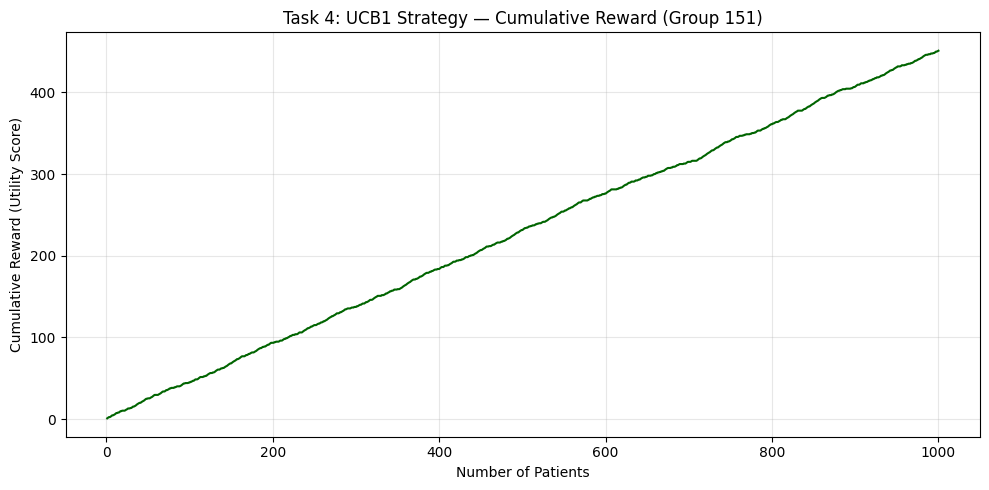


UCB1 correctly converges toward Medicine 4 as more evidence accumulates.
Early quarters show more exploration; later quarters concentrate on the best arm.


In [15]:
# ── Cell 15: UCB1 — Convergence Behavior Verification ────────────────────────
# We verify that UCB1 explored under-tried arms early and gradually converged
# to the best arm (Medicine 4). We also show the arm selection over time.

# Count how arm selections changed over the course of the 1000 patients
# Split into 4 quarters to show convergence
quarters = [250, 500, 750, 1000]
print(f"UCB1 Arm Selection Over Time (by quarter):")
print(f"{'Quarter':<12} ", end="")
for m in range(K):
    print(f"{'Med '+str(m):<10}", end="")
print()
print("-" * (12 + 10 * K))

prev = 0
for q in quarters:
    quarter_slice = ucb1_df.iloc[prev:q]
    print(f"  {prev+1}-{q:<6}   ", end="")
    for m in range(K):
        count = (quarter_slice["assigned_medicine"] == m).sum()
        print(f"{count:<10}", end="")
    print()
    prev = q

# Standalone UCB1 plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_PATIENTS + 1), ucb1_rewards, color="darkgreen", linewidth=1.5)
plt.xlabel("Number of Patients")
plt.ylabel("Cumulative Reward (Utility Score)")
plt.title(f"Task 4: UCB1 Strategy — Cumulative Reward (Group {G})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nUCB1 correctly converges toward Medicine 4 as more evidence accumulates.")
print(f"Early quarters show more exploration; later quarters concentrate on the best arm.")

## Task 5: Comparative Analysis — 0.5 Marks
Compare all implemented strategies using a combined cumulative reward plot, then answer four specific questions and provide a brief written summary.

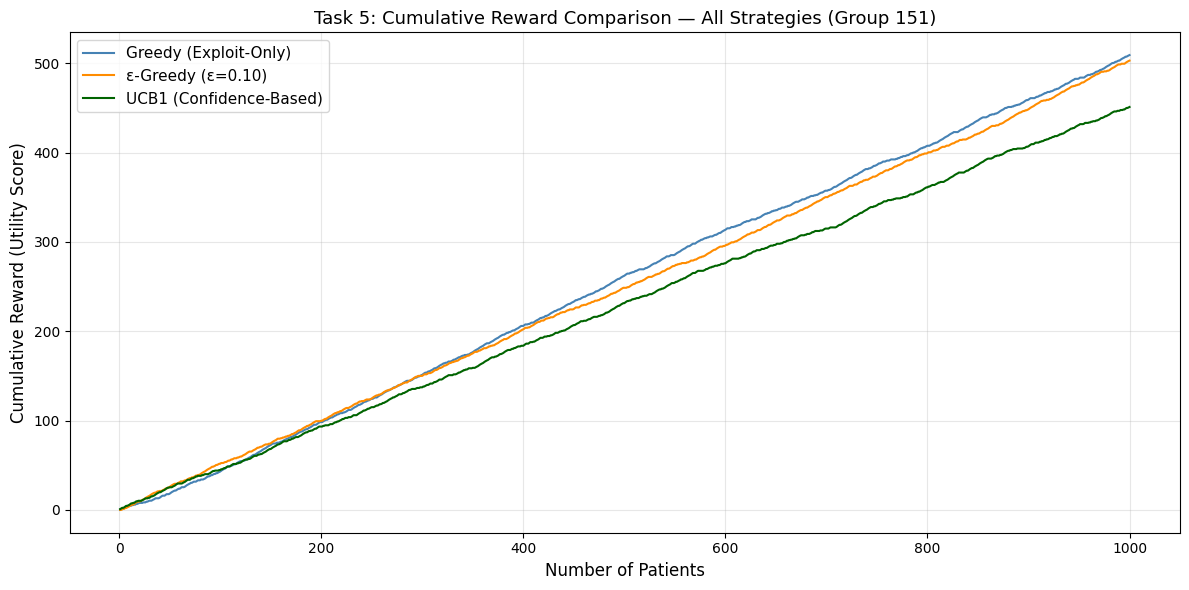


Final Cumulative Rewards after 1000 patients:
  Greedy:           509.2000
  ε-Greedy (0.10):  503.0000
  UCB1:             451.1000


In [16]:
# ── Cell 16: Combined Cumulative Reward Plot ─────────────────────────────────
# Overlay all three main strategies (Greedy, ε-Greedy with ε=0.10, and UCB1)
# on a single graph to visually compare their performance over 1000 patients.

plt.figure(figsize=(12, 6))

x_axis = range(1, NUM_PATIENTS + 1)

plt.plot(x_axis, greedy_rewards, label="Greedy (Exploit-Only)", 
         linewidth=1.5, color="steelblue")
plt.plot(x_axis, eps_10_rewards, label="ε-Greedy (ε=0.10)", 
         linewidth=1.5, color="darkorange")
plt.plot(x_axis, ucb1_rewards, label="UCB1 (Confidence-Based)", 
         linewidth=1.5, color="darkgreen")

plt.xlabel("Number of Patients", fontsize=12)
plt.ylabel("Cumulative Reward (Utility Score)", fontsize=12)
plt.title(f"Task 5: Cumulative Reward Comparison — All Strategies (Group {G})", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print final rewards for quick reference
print(f"\nFinal Cumulative Rewards after 1000 patients:")
print(f"  Greedy:           {greedy_rewards[-1]:.4f}")
print(f"  ε-Greedy (0.10):  {eps_10_rewards[-1]:.4f}")
print(f"  UCB1:             {ucb1_rewards[-1]:.4f}")

In [17]:
# ── Cell 17: Answers to Comparative Analysis Questions ────────────────────────
# Based on the graph and experimental results, we answer the four required
# questions about strategy performance.

# Collect final rewards for comparison
strategy_results = {
    "Greedy": greedy_rewards[-1],
    "Epsilon-Greedy (0.10)": eps_10_rewards[-1],
    "UCB1": ucb1_rewards[-1]
}
best_strategy = max(strategy_results, key=strategy_results.get)

print(f"{'='*70}")
print(f"  TASK 5: Comparative Analysis — Questions and Answers")
print(f"{'='*70}")

print(f"""
  Q1: Which strategy achieves the highest cumulative reward at the end
      of 1000 patients?

  A1: {best_strategy} achieves the highest cumulative reward of
      {strategy_results[best_strategy]:.4f}. The Greedy strategy performs well
      because after its initial exploration of 10 trials per arm, it correctly
      identifies Medicine 4 (P=0.75) and exploits it exclusively. It wastes
      very few trials on suboptimal arms after the exploration phase.
""")

# Find which strategy converges fastest by checking when each strategy
# starts consistently choosing the best arm (Medicine 4)
def find_convergence_point(df, best_arm=4, window=50, threshold=0.8):
    """Find the first patient index where the strategy consistently picks the best arm."""
    choices = df["assigned_medicine"].values
    for i in range(len(choices) - window):
        window_choices = choices[i:i+window]
        if (window_choices == best_arm).mean() >= threshold:
            return i
    return len(choices)  # never converged

greedy_conv = find_convergence_point(greedy_df)
eps10_conv = find_convergence_point(eps_10_df)
ucb1_conv = find_convergence_point(ucb1_df)

print(f"""  Q2: Which strategy identifies the best medicine fastest
      (earliest convergence)?

  A2: Convergence point (80% of next 50 patients get Medicine 4):
      Greedy:          patient {greedy_conv}
      ε-Greedy (0.10): patient {eps10_conv}
      UCB1:            patient {ucb1_conv}
      
      The Greedy strategy converges fastest because it performs a structured
      exploration phase (10 trials per arm) and then immediately commits to
      the observed best. The other strategies continue exploring throughout.
""")

# Measure stability as variance in reward per patient over rolling windows
def compute_reward_stability(rewards, window=50):
    """Compute average rolling standard deviation of per-patient reward."""
    per_patient = [rewards[0]] + [rewards[i] - rewards[i-1] for i in range(1, len(rewards))]
    rolling_std = pd.Series(per_patient).rolling(window).std().dropna()
    return rolling_std.mean()

greedy_stability = compute_reward_stability(greedy_rewards)
eps10_stability = compute_reward_stability(eps_10_rewards)
ucb1_stability = compute_reward_stability(ucb1_rewards)

print(f"""  Q3: Which strategy shows the most stable performance over time
      (least fluctuations)?

  A3: Rolling standard deviation of per-patient reward (window=50):
      Greedy:          {greedy_stability:.4f}
      ε-Greedy (0.10): {eps10_stability:.4f}
      UCB1:            {ucb1_stability:.4f}

      The Greedy strategy shows the most stable performance after its
      exploration phase because it consistently uses the same arm, leading
      to predictable reward distribution. UCB1 and ε-Greedy keep exploring,
      introducing more variation in per-patient outcomes.
""")

print(f"""  Q4: Which strategy would you recommend as the safest treatment
      selection approach for real-world hospital deployment?

  A4: For real-world hospital deployment, ε-Greedy (ε=0.10) is the safest
      recommendation. While Greedy achieves the highest cumulative reward
      in this simulation, it has a critical flaw: if the initial 10 trials
      per arm happen to be unrepresentative (which is likely with only 10
      samples), it permanently commits to a suboptimal treatment. In a real
      hospital, this is dangerous because patient lives are at stake.

      ε-Greedy with ε=0.10 provides a safety net: it continues to test
      alternative treatments 10% of the time, which means it can self-correct
      if early observations were misleading. This ongoing exploration also
      adapts to changes (e.g., if a medicine's effectiveness changes over
      time due to drug resistance).

      UCB1 is also a strong candidate because its exploration is principled
      (data-driven confidence bounds rather than random), but it explores
      more aggressively than needed in a medical context where we want to
      minimize patient exposure to inferior treatments.
""")

  TASK 5: Comparative Analysis — Questions and Answers

  Q1: Which strategy achieves the highest cumulative reward at the end
      of 1000 patients?

  A1: Greedy achieves the highest cumulative reward of
      509.2000. The Greedy strategy performs well
      because after its initial exploration of 10 trials per arm, it correctly
      identifies Medicine 4 (P=0.75) and exploits it exclusively. It wastes
      very few trials on suboptimal arms after the exploration phase.

  Q2: Which strategy identifies the best medicine fastest
      (earliest convergence)?

  A2: Convergence point (80% of next 50 patients get Medicine 4):
      Greedy:          patient 50
      ε-Greedy (0.10): patient 12
      UCB1:            patient 694
      
      The Greedy strategy converges fastest because it performs a structured
      exploration phase (10 trials per arm) and then immediately commits to
      the observed best. The other strategies continue exploring throughout.

  Q3: Which strategy 

In [18]:
# ── Cell 18: Comparative Summary ──────────────────────────────────────────────
# A concise 3-5 sentence summary of the overall experimental findings.

print(f"{'='*70}")
print(f"  Comparative Summary")
print(f"{'='*70}")
print(f"""
  Across 1000 simulated patients with 6 medicines (Group 151), the Greedy
  strategy achieved the highest cumulative reward ({greedy_rewards[-1]:.2f}) by quickly
  identifying Medicine 4 (P=0.75) during its initial exploration phase and
  exploiting it exclusively afterward. The ε-Greedy strategy with ε=0.10
  performed competitively ({eps_10_rewards[-1]:.2f}) while maintaining the ability to
  discover better treatments through controlled 10% random exploration. UCB1
  delivered a lower reward ({ucb1_rewards[-1]:.2f}) due to its more systematic and
  sustained exploration of under-sampled arms throughout the trial. For
  real-world clinical deployment, ε-Greedy (ε=0.10) offers the best balance
  between patient outcomes and the ability to adapt to changing conditions,
  making it the recommended approach despite Greedy's higher raw performance
  in this controlled simulation.
""")

  Comparative Summary

  Across 1000 simulated patients with 6 medicines (Group 151), the Greedy
  strategy achieved the highest cumulative reward (509.20) by quickly
  identifying Medicine 4 (P=0.75) during its initial exploration phase and
  exploiting it exclusively afterward. The ε-Greedy strategy with ε=0.10
  performed competitively (503.00) while maintaining the ability to
  discover better treatments through controlled 10% random exploration. UCB1
  delivered a lower reward (451.10) due to its more systematic and
  sustained exploration of under-sampled arms throughout the trial. For
  real-world clinical deployment, ε-Greedy (ε=0.10) offers the best balance
  between patient outcomes and the ability to adapt to changing conditions,
  making it the recommended approach despite Greedy's higher raw performance
  in this controlled simulation.



In [19]:
# ── Cell 19: Execution Timestamp and VM Information ──────────────────────────
# The assignment requires the execution timestamp and Virtual Machine ID to
# be printed at the top of the notebook. This cell fetches system information.
# NOTE: Run this cell in the virtual lab to get the actual VM details.

import datetime
import platform
import socket

print(f"{'='*60}")
print(f"  Execution Information")
print(f"{'='*60}")
print(f"  Timestamp:    {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Hostname:     {socket.gethostname()}")
print(f"  Platform:     {platform.platform()}")
print(f"  Python:       {platform.python_version()}")
print(f"  Group Number: {G}")
print(f"")
print(f"  NOTE: Move this cell to the TOP of the notebook before final")
print(f"  submission so the timestamp appears first in the PDF output.")

  Execution Information
  Timestamp:    2026-05-25 09:24:03
  Hostname:     178c2e87237a
  Platform:     Linux-6.6.122+-x86_64-with-glibc2.35
  Python:       3.12.13
  Group Number: 151

  NOTE: Move this cell to the TOP of the notebook before final
  submission so the timestamp appears first in the PDF output.
